## MRT Dataset Validation

- 597 MRT exits
- 186 unique MRT stations
- No missing station names
- No duplicate records
- Coordinates stored in EPSG:4326
- Average of 3.2 exits per station

Dataset is suitable for distance-based feature engineering.

In [1]:

from src.utils.paths import EXTERNAL_DATA_DIR
import pandas as pd
import geopandas as gpd

In [3]:
gdf = gpd.read_file(EXTERNAL_DATA_DIR / "LTAMRTStationExitGEOJSON.geojson")

In [5]:
gdf.head(10)

,OBJECTID,STATION_NA,EXIT_CODE,INC_CRC,FMEL_UPD_D,geometry
0,17885,BRIGHT HILL MRT STATION,Exit 1,CFB9350F44E8991A,20251202172807,POINT (103.83364 1.36404)
1,17886,BRIGHT HILL MRT STATION,Exit 2,F273E9D550B06062,20251202172807,POINT (103.83351 1.36328)
2,17887,BRIGHT HILL MRT STATION,Exit 4,BC4A442B12F99E85,20251202172807,POINT (103.83195 1.36316)
3,17888,BRIGHT HILL MRT STATION,Exit 3,2A45076ED986B275,20251202172807,POINT (103.83238 1.36218)
4,17889,UPPER THOMSON MRT STATION,Exit 2,3EA737829473A972,20251202172807,POINT (103.83183 1.35574)
5,17890,UPPER THOMSON MRT STATION,Exit 1,02A569EE1B9EC73B,20251202172807,POINT (103.83192 1.35483)
6,17891,UPPER THOMSON MRT STATION,Exit 5,2313E9492AA32861,20251202172807,POINT (103.83264 1.35442)
7,17892,UPPER THOMSON MRT STATION,Exit 3,A00E2C99CAD73E80,20251202172807,POINT (103.83392 1.35414)
8,17893,UPPER THOMSON MRT STATION,Exit 4,7A835D396BF0703F,20251202172807,POINT (103.83379 1.3535)
9,17894,CALDECOTT MRT STATION,Exit 2,00BCCDD48A0A19AB,20251202172807,POINT (103.84039 1.33826)


In [6]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    597 non-null    int32   
 1   STATION_NA  597 non-null    str     
 2   EXIT_CODE   597 non-null    str     
 3   INC_CRC     597 non-null    str     
 4   FMEL_UPD_D  597 non-null    str     
 5   geometry    597 non-null    geometry
dtypes: geometry(1), int32(1), str(4)
memory usage: 25.8 KB


In [7]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
gdf["STATION_NA"].nunique()

186

In [9]:
gdf["STATION_NA"].value_counts().describe()

count    186.000000
mean       3.209677
std        1.951884
min        1.000000
25%        2.000000
50%        2.000000
75%        4.000000
max       13.000000
Name: count, dtype: float64

In [10]:
gdf["STATION_NA"].isna().sum()

np.int64(0)

In [11]:
gdf.duplicated().sum()

np.int64(0)

In [12]:
station_points = (gdf.dissolve(by="STATION_NA"))


In [13]:
station_points["geometry"] = (station_points.geometry.centroid)

C:\Users\Tahir C D\AppData\Local\Temp\ipykernel_10088\1550328208.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  station_points["geometry"] = (station_points.geometry.centroid)


In [14]:
station_points.head()

,geometry,OBJECTID,EXIT_CODE,INC_CRC,FMEL_UPD_D
STATION_NA,,,,,
ADMIRALTY MRT STATION,POINT (103.80086 1.44041),17920,Exit C,887FE97DECFFEA05,20251202172807
ALJUNIED MRT STATION,POINT (103.88248 1.31636),17949,Exit B,7C42B43D848F246C,20251202172807
ANG MO KIO MRT STATION,POINT (103.84968 1.36962),18090,Exit D,2FA1606517F7F394,20251202172807
BAKAU LRT STATION,POINT (103.90546 1.38801),17652,Exit A,8A3C1E7317417FD2,20251202172807
BANGKIT LRT STATION,POINT (103.77259 1.37985),18134,Exit A,B7DF61CC7C6C3B13,20251202172807


In [16]:
station_points = station_points[["geometry"]].reset_index()

In [17]:
station_points.shape

(186, 2)

In [18]:
station_points.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [19]:
station_points.head()

,STATION_NA,geometry
0,ADMIRALTY MRT STATION,POINT (103.80086 1.44041)
1,ALJUNIED MRT STATION,POINT (103.88248 1.31636)
2,ANG MO KIO MRT STATION,POINT (103.84968 1.36962)
3,BAKAU LRT STATION,POINT (103.90546 1.38801)
4,BANGKIT LRT STATION,POINT (103.77259 1.37985)


<Axes: >

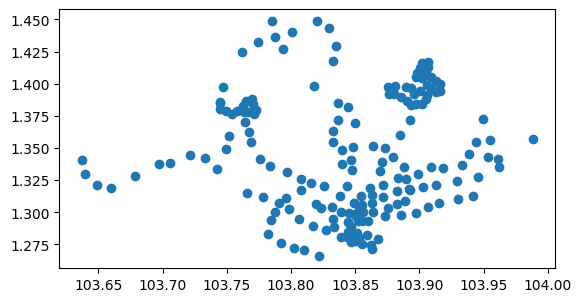

In [20]:
station_points.plot()